In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (12.0, 9.0)


In [17]:
np.random.seed(42)

X = np.arange(1, 21)
Y = 2 * X + 1 + np.random.normal(0, 2, 20)

data = pd.DataFrame({
    'X': X,
    'Y': Y
})

data.to_csv('data.csv', index=False)

print("Dataset created successfully!")
print(data.head())


Dataset created successfully!
   X          Y
0  1   3.993428
1  2   4.723471
2  3   8.295377
3  4  12.046060
4  5  10.531693


In [18]:
data = pd.read_csv('data.csv')

X = data.iloc[:, 0]
Y = data.iloc[:, 1]

print(data.head())


   X          Y
0  1   3.993428
1  2   4.723471
2  3   8.295377
3  4  12.046060
4  5  10.531693


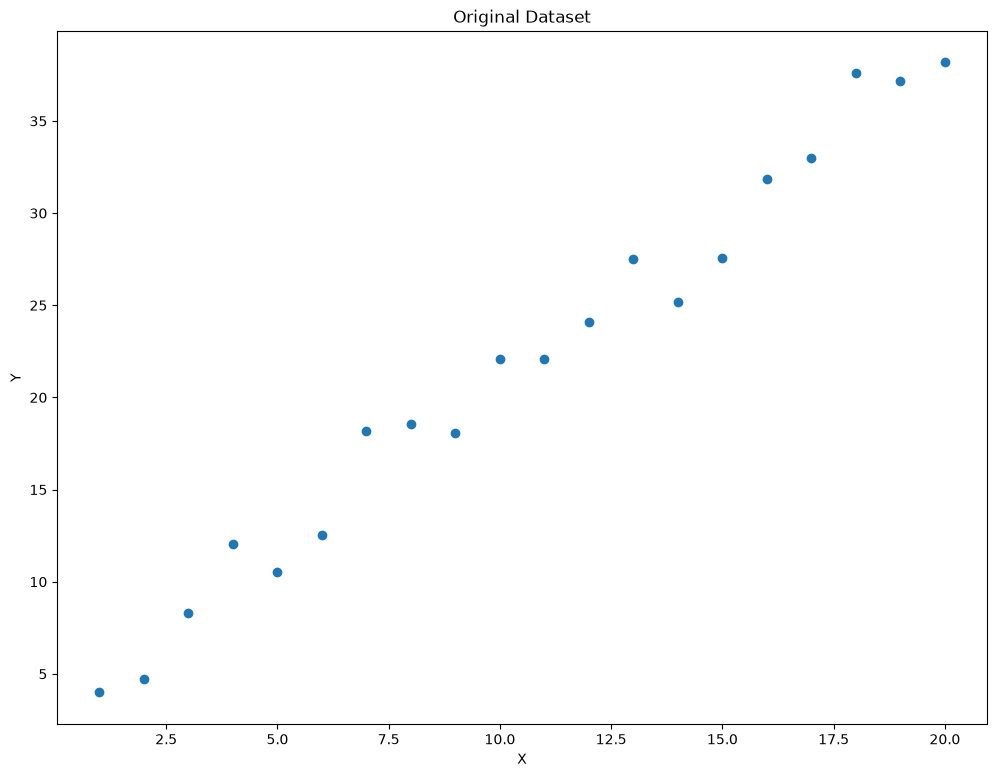

In [19]:
plt.scatter(X, Y)

plt.title('Original Dataset')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()


In [20]:
def manual_linear_regression(X_train, Y_train):
    X_mean = np.mean(X_train)
    Y_mean = np.mean(Y_train)

    num = 0
    den = 0

    for i in range(len(X_train)):
        num += (X_train.iloc[i] - X_mean) * (Y_train.iloc[i] - Y_mean)
        den += (X_train.iloc[i] - X_mean) ** 2

    m = num / den
    c = Y_mean - m * X_mean

    return m, c


In [21]:
X_train_80, X_test_20, Y_train_80, Y_test_20 = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train_80))
print("Testing samples:", len(X_test_20))

Training samples: 16
Testing samples: 4


In [22]:
X_train_70, X_test_30, Y_train_70, Y_test_30 = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42
)

print("Training samples:", len(X_train_70))
print("Testing samples:", len(X_test_30))


Training samples: 14
Testing samples: 6


In [23]:
m_80, c_80 = manual_linear_regression(
    X_train_80,
    Y_train_80
)

Y_pred_80 = m_80 * X_test_20 + c_80

print("80-20 Model")
print(f"Slope (m): {m_80:.4f}")
print(f"Intercept (c): {c_80:.4f}")


80-20 Model
Slope (m): 1.7065
Intercept (c): 3.7318


In [24]:
m_70, c_70 = manual_linear_regression(
    X_train_70,
    Y_train_70
)

Y_pred_70 = m_70 * X_test_30 + c_70

print("70-30 Model")
print(f"Slope (m): {m_70:.4f}")
print(f"Intercept (c): {c_70:.4f}")

70-30 Model
Slope (m): 1.6806
Intercept (c): 4.2001


In [25]:
MSE_80 = mean_squared_error(
    Y_test_20,
    Y_pred_80
)

r2_80 = r2_score(
    Y_test_20,
    Y_pred_80
)

print("80-20 Split Results:")
print(f"Slope (m): {m_80:.4f}")
print(f"Intercept (c): {c_80:.4f}")
print(f"MSE: {MSE_80:.4f}")
print(f"R² Score: {r2_80:.4f}")


80-20 Split Results:
Slope (m): 1.7065
Intercept (c): 3.7318
MSE: 4.6926
R² Score: 0.9800


In [26]:
MSE_70 = mean_squared_error(
    Y_test_30,
    Y_pred_70
)

r2_70 = r2_score(
    Y_test_30,
    Y_pred_70
)

print("70-30 Split Results:")
print(f"Slope (m): {m_70:.4f}")
print(f"Intercept (c): {c_70:.4f}")
print(f"MSE: {MSE_70:.4f}")
print(f"R² Score: {r2_70:.4f}")


70-30 Split Results:
Slope (m): 1.6806
Intercept (c): 4.2001
MSE: 4.4997
R² Score: 0.9725


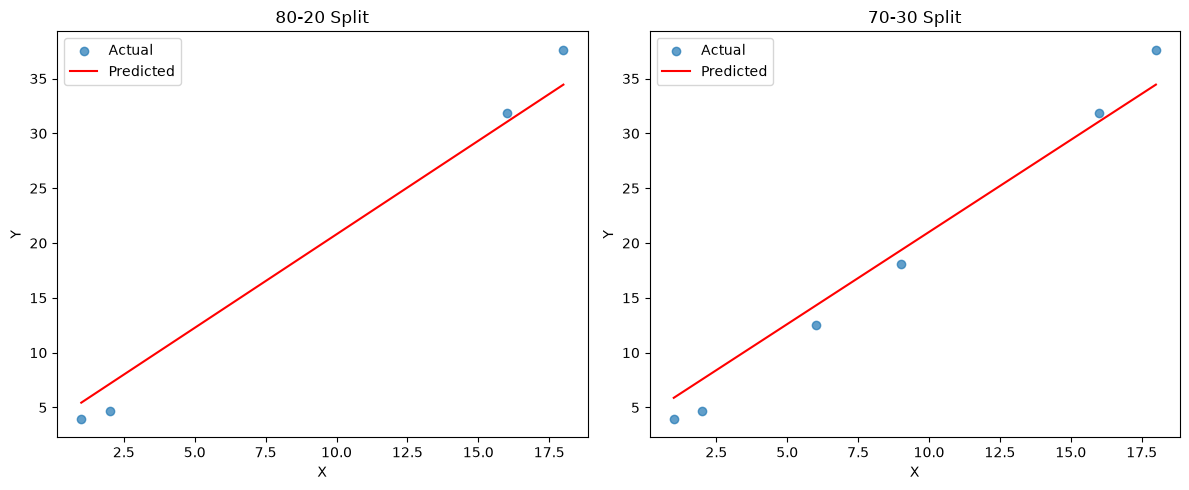

In [27]:
plt.figure(figsize=(12, 5))

# 80-20 Split
plt.subplot(1, 2, 1)

plt.scatter(
    X_test_20,
    Y_test_20,
    alpha=0.7,
    label='Actual'
)

plt.plot(
    [min(X_test_20), max(X_test_20)],
    [min(Y_pred_80), max(Y_pred_80)],
    color='red',
    label='Predicted'
)

plt.title('80-20 Split')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()


# 70-30 Split
plt.subplot(1, 2, 2)

plt.scatter(
    X_test_30,
    Y_test_30,
    alpha=0.7,
    label='Actual'
)

plt.plot(
    [min(X_test_30), max(X_test_30)],
    [min(Y_pred_70), max(Y_pred_70)],
    color='red',
    label='Predicted'
)

plt.title('70-30 Split')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()


In [28]:
print("=" * 50)
print("PERFORMANCE ANALYSIS")
print("=" * 50)

if MSE_80 < MSE_70:
    print("• 80-20 split performs BETTER based on MSE")
else:
    print("• 70-30 split performs BETTER based on MSE")

if r2_80 > r2_70:
    print("• 80-20 split has HIGHER R² Score")
else:
    print("• 70-30 split has HIGHER R² Score")


PERFORMANCE ANALYSIS
• 70-30 split performs BETTER based on MSE
• 80-20 split has HIGHER R² Score


In [29]:
print("\nModel Efficiency:")

print(
    f"• 80-20 Split: "
    f"MSE = {MSE_80:.4f}, "
    f"R² = {r2_80:.4f}"
)

print(
    f"• 70-30 Split: "
    f"MSE = {MSE_70:.4f}, "
    f"R² = {r2_70:.4f}"
)



Model Efficiency:
• 80-20 Split: MSE = 4.6926, R² = 0.9800
• 70-30 Split: MSE = 4.4997, R² = 0.9725


In [30]:
print("\nConclusion:")

if r2_80 > 0.8 and r2_70 > 0.8:
    print("• Both models show GOOD performance (R² > 0.8)")
elif r2_80 > 0.6 or r2_70 > 0.6:
    print("• Models show MODERATE performance")
else:
    print("• Models show POOR performance")

print("• Lower MSE indicates better performance")
print("• Higher R² Score indicates better performance")



Conclusion:
• Both models show GOOD performance (R² > 0.8)
• Lower MSE indicates better performance
• Higher R² Score indicates better performance
